In [65]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Literal
from IPython.display import Image

In [66]:
class Quadratic(TypedDict):
    a: float
    b: float
    c: float
    D: float
    roots: list[float]
    root_type: str

In [67]:
def solevD(quadratic: Quadratic) -> Quadratic:
    a, b, c = quadratic['a'], quadratic['b'], quadratic['c']
    D = b**2 - 4*a*c
    quadratic['D'] = D
    return quadratic

def real_two_roots(quadratic: Quadratic) -> bool:
    D = quadratic['D']
    sqrt_D = D**0.5
    quadratic['roots'] = [(-quadratic['b'] + sqrt_D) / (2*quadratic['a']),
                            (-quadratic['b'] - sqrt_D) / (2*quadratic['a'])]
    quadratic['root_type'] = 'two real roots'
    return quadratic

def no_real_roots(quadratic: Quadratic) -> bool:
    D = quadratic['D']
    quadratic['roots'] = []
    quadratic['root_type'] = 'no real roots'
    return quadratic

def one_real_root(quadratic: Quadratic) -> bool:
    D = quadratic['D']
    quadratic['roots'] = [-quadratic['b'] / (2*quadratic['a'])]
    quadratic['root_type'] = 'one real root'
    return quadratic

# Without adding Literal type in return, workflow graph image looks weird 
def check_root_type(quadratic: Quadratic) -> Literal['real_two_roots', 'one_real_root', 'no_real_roots']:
    D = quadratic['D']
    if D > 0:
        return 'real_two_roots' # this name should match with node name while adding it to graph
    elif D == 0:
        return 'one_real_root'
    else:
        return 'no_real_roots'

In [68]:
def show_workflow_image(workflow: StateGraph) -> Image:
    return Image(workflow.get_graph().draw_mermaid_png())

In [69]:
# Graph
graph = StateGraph(Quadratic)

# Nodes
graph.add_node("solve discriminant", solevD)
graph.add_node("real_two_roots", real_two_roots)
graph.add_node("no_real_roots", no_real_roots)
graph.add_node("one_real_root", one_real_root)

# nodes
graph.add_edge(START, "solve discriminant")
graph.add_conditional_edges("solve discriminant", check_root_type)
graph.add_edge("real_two_roots", END)
graph.add_edge("no_real_roots", END)
graph.add_edge("one_real_root", END)

In [70]:
workflow = graph.compile()

In [71]:
# Real Roots
initial_state = Quadratic(a=1, b=-3, c=2, D=0.0, roots=[], root_type="")
final_state = workflow.invoke(initial_state)
print(final_state)

{'a': 1, 'b': -3, 'c': 2, 'D': 1, 'roots': [2.0, 1.0], 'root_type': 'two real roots'}


In [72]:
# One Real Root
initial_state = Quadratic(a=1, b=-2, c=1, D=0.0, roots=[], root_type="")
final_state = workflow.invoke(initial_state)
print(final_state)

{'a': 1, 'b': -2, 'c': 1, 'D': 0, 'roots': [1.0], 'root_type': 'one real root'}


In [73]:
# No Real Root
initial_state = Quadratic(a=1, b=2, c=5, D=0.0, roots=[], root_type="")
final_state = workflow.invoke(initial_state)
print(final_state)

{'a': 1, 'b': 2, 'c': 5, 'D': -16, 'roots': [], 'root_type': 'no real roots'}


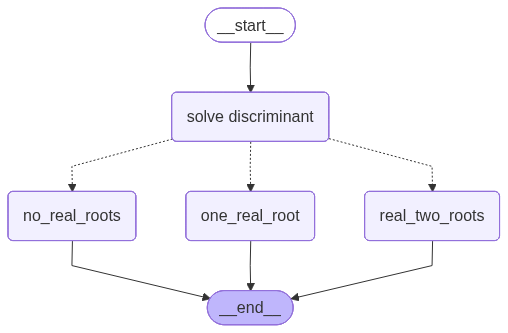

In [74]:
show_workflow_image(workflow)